In [1]:
import os
import pyarrow as pa

_NCPU = os.cpu_count() or 1
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | pyarrow {pa.__version__}", flush=True)

Running with 8 CPU cores | pyarrow 24.0.0


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [3]:
FEATURE_DATASET = "1_dispatch_price.parquet"
STATE = "NSW"
OUTPUT_RESOLUTION = 30
HORIZONS_PER_WINDOW = 8          # 8 × 30 min = 4 h

In [4]:
def load_features(
        features_path: Path,
        pipeline_start: pd.Timestamp,
        pipeline_end: pd.Timestamp,
) -> pd.DataFrame:
    features = pd.read_parquet(features_path, filters=[
        ('SETTLEMENTDATE', '>=', pipeline_start),
        ('SETTLEMENTDATE', '<=', pipeline_end),
    ])
    _TARGET_COLS = {"nsw_price", "qld_price", "sa_price", "vic_price", "price"}
    features = features.drop(columns=[c for c in features.columns if c in _TARGET_COLS])
    return features.loc[:pipeline_end]


def load_targets(state:str):
    future_prediction_targets = pd.read_parquet(f"../3_Targets build/Target_data/{state.lower()}_targets.parquet")
    return future_prediction_targets




# Make calls
features = load_features(
    features_path=Path(f"../2_Features build/Feature_data/{FEATURE_DATASET}"),   # Select future dataset
    pipeline_start=pd.Timestamp("2019/01/01"),
    pipeline_end=pd.Timestamp("2026/01/01"),
)

future_prediction_targets = load_targets(
    state=STATE     # select state
    )

# Align on index
future_prediction_targets = future_prediction_targets.loc[features.index]
features = features.loc[future_prediction_targets.index]

In [5]:
"""
Rank features

MI ranking: measures mutual information — a non-linear, information-theoretic score. It answers "does knowing this feature reduce uncertainty about the target?",
capturing non-linear dependencies too. Targets are pre-aggregated to output_resolution_minutes before scoring,
so MI is computed directly at the output resolution (96 × 30-min horizons).
"""

def rank_features(
    features: pd.DataFrame,
    future_prediction_targets: pd.DataFrame,
    feature_selection_subsample_start: pd.Timestamp,
    feature_selection_subsample_end: pd.Timestamp,
    mi_subsample: int = 20_000,
    output_resolution_minutes: int = 30,
) -> tuple[pd.Series, pd.DataFrame, np.ndarray, pd.DataFrame, list[str], list[str]]:
    # Runtime guide (96 output horizons, 638 features, 96 CPUs — 1 job per core):
    #   mi_subsample=  5_000 →  ~0.5 min  (fast, lower accuracy)
    #   mi_subsample= 20_000 →  ~2 min    (good balance)
    #   mi_subsample= 50_000 →  ~6 min    (high accuracy)
    #   mi_subsample=100_000 → ~12 min    (very high accuracy)

    from joblib import Parallel, delayed

    feature_cols = list(features.columns)
    target_cols  = list(future_prediction_targets.columns)
    horizons     = len(target_cols)

    def _filter_data_for_feature_time_range_subset():
        features_subset = features.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        targets_subset  = future_prediction_targets.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        shared_index    = features_subset.index.intersection(targets_subset.index)
        return features_subset.loc[shared_index], targets_subset.loc[shared_index]

    features_subset, targets_subset = _filter_data_for_feature_time_range_subset()

    features_subset = features_subset.values.astype(np.float32)
    targets_subset = targets_subset.reset_index(drop=True)

    def _subsample_features():
        seed = np.random.default_rng(42)
        n_samples = min(mi_subsample, len(features_subset))
        subsample_index = seed.choice(len(features_subset), size=n_samples, replace=False)
        subsample_index.sort()
        return features_subset[subsample_index], targets_subset.iloc[subsample_index]

    X_subsample, y_subsample = _subsample_features()

    def _mutual_information_scoring():
        # Pre-aggregate 5-min targets to output_resolution_minutes before scoring.
        # This scores MI directly at the output resolution, which is 6× fewer
        # computations than scoring 576 5-min horizons and aggregating afterwards.
        y_arr_5min = y_subsample[target_cols].values.astype(np.float32)  # (n, 576)
        n_features = X_subsample.shape[1]
        n          = X_subsample.shape[0]

        # Aggregate 5-min targets → output_resolution_minutes buckets
        bucket_size = max(1, output_resolution_minutes // 5)
        n_buckets   = horizons // bucket_size
        n_raw       = n_buckets * bucket_size
        # (n, n_buckets, bucket_size) → mean over last axis → (n, n_buckets)
        y_arr = y_arr_5min[:, :n_raw].reshape(n, n_buckets, bucket_size).mean(axis=2)
        bucket_cols = [f"h{i + 1}" for i in range(n_buckets)]

        # Split features into chunks so n_tasks >> n_workers → multiple rounds → smooth progress bar.
        # MI is a pairwise measure (each feature scored independently), so chunking features
        # has zero effect on results — only on how work is dispatched to workers.
        target_rounds = 10
        n_feat_chunks = max(1, (target_rounds * _NCPU + n_buckets - 1) // n_buckets)
        chunk_edges   = np.array_split(np.arange(n_features), n_feat_chunks)
        feat_chunks   = [(int(c[0]), int(c[-1]) + 1) for c in chunk_edges if len(c) > 0]
        n_tasks       = n_buckets * len(feat_chunks)

        print(
            f"  MI scoring: {n_features} features × {n_buckets} horizons ({output_resolution_minutes}-min) "
            f"| subsample n={n:,} | {n_tasks} tasks across {_NCPU} CPUs (~{n_tasks // _NCPU} rounds)",
            flush=True,
        )

        def _score_chunk(j, fs, fe):
            return j, fs, fe, mutual_info_regression(
                X_subsample[:, fs:fe], y_arr[:, j],
                discrete_features=False, n_neighbors=3, random_state=42,
            )

        gen = Parallel(n_jobs=-1, backend="loky", batch_size=1, return_as="generator_unordered")(
            delayed(_score_chunk)(j, fs, fe)
            for j in range(n_buckets) for fs, fe in feat_chunks
        )
        scores = np.empty((n_features, n_buckets))
        for j, fs, fe, chunk_scores in tqdm(gen, total=n_tasks, desc="MI scoring", leave=True):
            scores[fs:fe, j] = chunk_scores

        mi_matrix = pd.DataFrame(scores, index=feature_cols, columns=bucket_cols)
        feature_cols_ranked = mi_matrix.mean(axis=1).sort_values(ascending=False)
        return feature_cols_ranked, mi_matrix

    feature_cols_ranked, mi_matrix = _mutual_information_scoring()

    return feature_cols_ranked, mi_matrix, features_subset, targets_subset, feature_cols, target_cols


feature_cols_ranked, mi_matrix, features_subset, targets_subset, feature_cols, target_cols = rank_features(
    features=features,
    future_prediction_targets=future_prediction_targets,
    feature_selection_subsample_start=pd.Timestamp("2019/01/01"),
    feature_selection_subsample_end=pd.Timestamp("2023/01/01"),
    mi_subsample=1_000,
    output_resolution_minutes=OUTPUT_RESOLUTION,
)

print(f"Ranked all {len(feature_cols_ranked)} provided features.")


  MI scoring: 634 features × 96 horizons (30-min) | subsample n=1,000 | 96 tasks across 8 CPUs (~12 rounds)


MI scoring: 100%|██████████| 96/96 [00:22<00:00,  4.33it/s]

Ranked all 634 provided features.


In [6]:
dataset_stem = Path(FEATURE_DATASET).stem

# Base ranking columns + per-horizon MI scores (h1…h96) as additional columns
ranked_path = f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet"
df_base = pd.DataFrame({
    "rank":            range(1, len(feature_cols_ranked) + 1),
    "feature":         feature_cols_ranked.index,
    "mean_mi":         feature_cols_ranked.values,
    "state":           STATE,
    "feature_dataset": dataset_stem,
}).set_index("feature")

# mi_matrix rows = features (same order as feature_cols_ranked after reindex)
df_horizons = mi_matrix.reindex(feature_cols_ranked.index)

df_ranking = pd.concat([df_base, df_horizons], axis=1).reset_index(names="feature")
df_ranking.to_parquet(ranked_path, index=False)

print(f"Saved {len(df_ranking)} features × {len(mi_matrix.columns)} horizons → {ranked_path}")


Saved 634 features × 96 horizons → Selected_features/NSW_1_dispatch_price_feature_ranking.parquet


In [7]:
df = pd.read_parquet(f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet")
df[:10]

,feature,rank,mean_mi,state,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
0,nsw_price_q90_336,1,0.520032,NSW,1_dispatch_price,0.642081,0.589403,0.611350,0.620653,0.582265,0.577282,0.569113,0.562880,0.559270,0.526846,0.553539,0.527778,0.527400,0.462414,0.531032,0.535137,0.535320,0.527342,0.599072,0.537092,0.542472,0.611406,0.549680,0.607448,0.596546,0.505247,0.508167,0.526657,0.471996,0.485707,0.461973,0.453399,0.475934,0.473168,0.510491,0.561398,0.560235,0.550963,0.558377,0.568222,0.606966,0.586494,0.604233,0.552777,0.585439,0.579696,0.592701,0.554512,0.492356,0.553480,0.561592,0.533400,0.467711,0.485854,0.450755,0.485576,0.487768,0.429216,0.444892,0.479089,0.465724,0.459340,0.463678,0.436292,0.419428,0.498793,0.500654,0.491970,0.555001,0.507277,0.470142,0.475673,0.506308,0.480966,0.453410,0.438656,0.417932,0.418802,0.481689,0.471094,0.478408,0.451781,0.530644,0.517987,0.579305,0.531172,0.485033,0.487083,0.503964,0.538901,0.517936,0.537947,0.532404,0.513733,0.507645,0.505061
1,nsw_price_asinh_rmean_336,2,0.508457,NSW,1_dispatch_price,0.669668,0.601920,0.612534,0.636281,0.627400,0.601567,0.624224,0.540811,0.537632,0.523939,0.526626,0.527934,0.514671,0.525278,0.517664,0.516195,0.486623,0.531660,0.556299,0.523825,0.540229,0.512724,0.565422,0.523272,0.551111,0.512797,0.484811,0.512637,0.470028,0.464717,0.450288,0.460500,0.489705,0.546980,0.546631,0.575655,0.524799,0.536079,0.551488,0.537154,0.582216,0.593880,0.580602,0.556457,0.543631,0.570113,0.535440,0.577510,0.475813,0.491969,0.485420,0.506332,0.470341,0.498873,0.474476,0.459533,0.452788,0.479713,0.437834,0.421766,0.426041,0.451613,0.457722,0.462982,0.475821,0.492980,0.487037,0.483651,0.539279,0.481138,0.457238,0.489295,0.422522,0.492058,0.445113,0.442738,0.428636,0.399256,0.420610,0.463200,0.456595,0.436282,0.497134,0.475553,0.483733,0.448766,0.499841,0.500438,0.471376,0.495269,0.492289,0.545606,0.504920,0.498430,0.510044,0.522200
2,nsw_price_rmean_2016,3,0.496085,NSW,1_dispatch_price,0.527689,0.566931,0.505186,0.548956,0.533929,0.547354,0.498999,0.514184,0.565817,0.535580,0.503777,0.527859,0.483552,0.513701,0.499600,0.539287,0.548703,0.513125,0.533715,0.574611,0.527763,0.513766,0.524695,0.505945,0.508257,0.507659,0.471340,0.508754,0.497336,0.495440,0.452167,0.401541,0.453020,0.511102,0.453084,0.491286,0.521304,0.485608,0.501109,0.468756,0.525776,0.540875,0.527598,0.474595,0.534144,0.486363,0.509003,0.469705,0.433704,0.443740,0.477701,0.517582,0.453206,0.534580,0.483386,0.472560,0.472733,0.459443,0.428083,0.497421,0.447383,0.485964,0.456664,0.471321,0.496966,0.544277,0.481334,0.512906,0.527601,0.497474,0.456383,0.532066,0.475015,0.458292,0.459867,0.447893,0.506253,0.442617,0.475158,0.490255,0.442631,0.500104,0.500882,0.495819,0.490455,0.519124,0.523606,0.492460,0.485441,0.473860,0.505556,0.482530,0.471714,0.476842,0.479530,0.493238
3,nsw_price_rmean_336,4,0.474657,NSW,1_dispatch_price,0.657172,0.586954,0.579340,0.596623,0.551995,0.577307,0.562943,0.477005,0.491564,0.496701,0.501393,0.480718,0.454702,0.502515,0.482148,0.456029,0.486751,0.501782,0.498066,0.496577,0.487750,0.482443,0.491294,0.509372,0.564814,0.481812,0.504632,0.474702,0.427545,0.435335,0.434403,0.456559,0.438363,0.497473,0.500490,0.503864,0.523297,0.520139,0.531438,0.497326,0.557172,0.575362,0.519130,0.517431,0.538631,0.508878,0.492301,0.500819,0.465467,0.471322,0.495367,0.484133,0.457836,0.454444,0.444604,0.422700,0.426260,0.404515,0.431449,0.419650,0.393302,0.384979,0.394534,0.415234,0.428442,0.486852,0.434582,0.448540,0.485006,0.424201,0.404562,0.458099,0.392744,0.457079,0.445864,0.429143,0.392435,0.382612,0.406104,0.429181,0.437223,0.392176,0.439278,0.453144,0.477892,0.4

In [8]:
from joblib import Parallel, delayed


N_WINDOWS = len(mi_matrix.columns) // HORIZONS_PER_WINDOW   # 12

horizon_cols = list(mi_matrix.columns)   # h1 … h96

# Pre-compute normalised feature matrix once — reused across all 12 windows
_feat_mean = features_subset.mean(axis=0, keepdims=True)
_feat_std  = features_subset.std(axis=0, keepdims=True) + 1e-8
_feat_norm = (features_subset - _feat_mean) / _feat_std
_feat_idx  = {name: idx for idx, name in enumerate(feature_cols)}

# Pre-compute full Pearson correlation matrix once (single BLAS matmul).
# Shape: (n_features, n_features). Dedup checks become O(1) index lookups
# instead of O(k × n_samples) dot products + vstack on every iteration.
_corr_matrix = (_feat_norm.T @ _feat_norm) / _feat_norm.shape[0]
print(f"Correlation matrix: {_corr_matrix.shape}  ({_corr_matrix.nbytes / 1e6:.1f} MB)", flush=True)


def _window_unique_features(ranked_window: pd.Series, corr_threshold: float = 0.80) -> list[str]:
    """Greedy Pearson dedup — O(1) per check via precomputed correlation matrix."""
    unique: list[str] = []
    selected_indices: list[int] = []
    for feat, _ in ranked_window.items():
        fi = _feat_idx[feat]
        if selected_indices and np.abs(_corr_matrix[selected_indices, fi]).max() > corr_threshold:
            continue
        selected_indices.append(fi)
        unique.append(feat)
    return unique or list(ranked_window.index)


def _process_window(w: int):
    col_start     = w * HORIZONS_PER_WINDOW
    col_end       = col_start + HORIZONS_PER_WINDOW
    label         = f"h{col_start + 1:02d}_h{col_end:02d}"   # h01_h08 … h89_h96
    win_cols      = horizon_cols[col_start:col_end]
    mi_window     = mi_matrix[win_cols]
    ranked_window = mi_window.mean(axis=1).sort_values(ascending=False)
    selected      = _window_unique_features(ranked_window)
    return w, label, mi_window, selected


window_selections  = {}   # label → ranked + deduped feature list for that window
window_mi_matrices = {}   # label → mi_matrix slice (n_features × 8 horizons)

gen = Parallel(n_jobs=-1, prefer="threads", return_as="generator_unordered")(
    delayed(_process_window)(w) for w in range(N_WINDOWS)
)

raw_results = []
for result in tqdm(gen, total=N_WINDOWS, desc="Window dedup"):
    raw_results.append(result)

for w, label, mi_window, selected in sorted(raw_results, key=lambda x: x[0]):
    window_mi_matrices[label] = mi_window
    window_selections[label]  = selected
    print(f"  {label}: {len(selected):3d} unique features")

print(f"\n{N_WINDOWS} windows × {HORIZONS_PER_WINDOW} horizons ({HORIZONS_PER_WINDOW * OUTPUT_RESOLUTION // 60} h each) — per-window selections ready.")


Correlation matrix: (634, 634)  (1.6 MB)


Window dedup: 100%|██████████| 12/12 [00:00<00:00, 153.84it/s]

  h01_h08: 421 unique features
  h09_h16: 423 unique features
  h17_h24: 424 unique features
  h25_h32: 425 unique features
  h33_h40: 422 unique features
  h41_h48: 426 unique features
  h49_h56: 421 unique features
  h57_h64: 420 unique features
  h65_h72: 425 unique features
  h73_h80: 424 unique features
  h81_h88: 424 unique features
  h89_h96: 423 unique features

12 windows × 8 horizons (4 h each) — per-window selections ready.


In [9]:
# Build per-window feature groupings parquet
# Columns: window, window_start_h, window_end_h, rank_in_window, feature, mean_mi_window
rows = []
for label, feats in window_selections.items():
    start_h, end_h = label.split("_")   # e.g. "h01", "h08"
    ranked_window = window_mi_matrices[label].mean(axis=1)
    for rank, feat in enumerate(feats, start=1):
        rows.append({
            "window":          label,
            "window_start_h":  start_h,
            "window_end_h":    end_h,
            "rank_in_window":  rank,
            "feature":         feat,
            "mean_mi_window":  float(ranked_window.loc[feat]),
            "state":           STATE,
            "feature_dataset": dataset_stem,
        })

df_windows = pd.DataFrame(rows)
windows_path = f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet"
df_windows.to_parquet(windows_path, index=False)
print(f"Saved {len(df_windows)} rows ({N_WINDOWS} windows) → {windows_path}")

Saved 5078 rows (12 windows) → Selected_features/NSW_1_dispatch_price_feature_ranking.parquet


In [10]:
df_windows = pd.read_parquet(f"Selected_features/{STATE}_{dataset_stem}_feature_ranking.parquet")
df_windows[:10]

,window,window_start_h,window_end_h,rank_in_window,feature,mean_mi_window,state,feature_dataset
0,h01_h08,h01,h08,1,nsw_price_rmean_4,0.851929,NSW,1_dispatch_price
1,h01_h08,h01,h08,2,nsw_price_asinh_lag_1,0.816269,NSW,1_dispatch_price
2,h01_h08,h01,h08,3,nsw_price_rmin_4,0.790210,NSW,1_dispatch_price
3,h01_h08,h01,h08,4,nsw_price_rmax_8,0.729160,NSW,1_dispatch_price
4,h01_h08,h01,h08,5,nsw_price_lag_4,0.723603,NSW,1_dispatch_price
5,h01_h08,h01,h08,6,nsw_price_lag_3,0.710219,NSW,1_dispatch_price
6,h01_h08,h01,h08,7,nsw_price_lag_6,0.695541,NSW,1_dispatch_price
7,h01_h08,h01,h08,8,nsw_price_rmean_24,0.694389,NSW,1_dispatch_price
8,h01_h08,h01,h08,9,nsw_price_rmin_24,0.660876,NSW,1_dispatch_price
9,h01_h08,h01,h08,10,nsw_price_lag_8,0.651397,NSW,1_dispatch_price


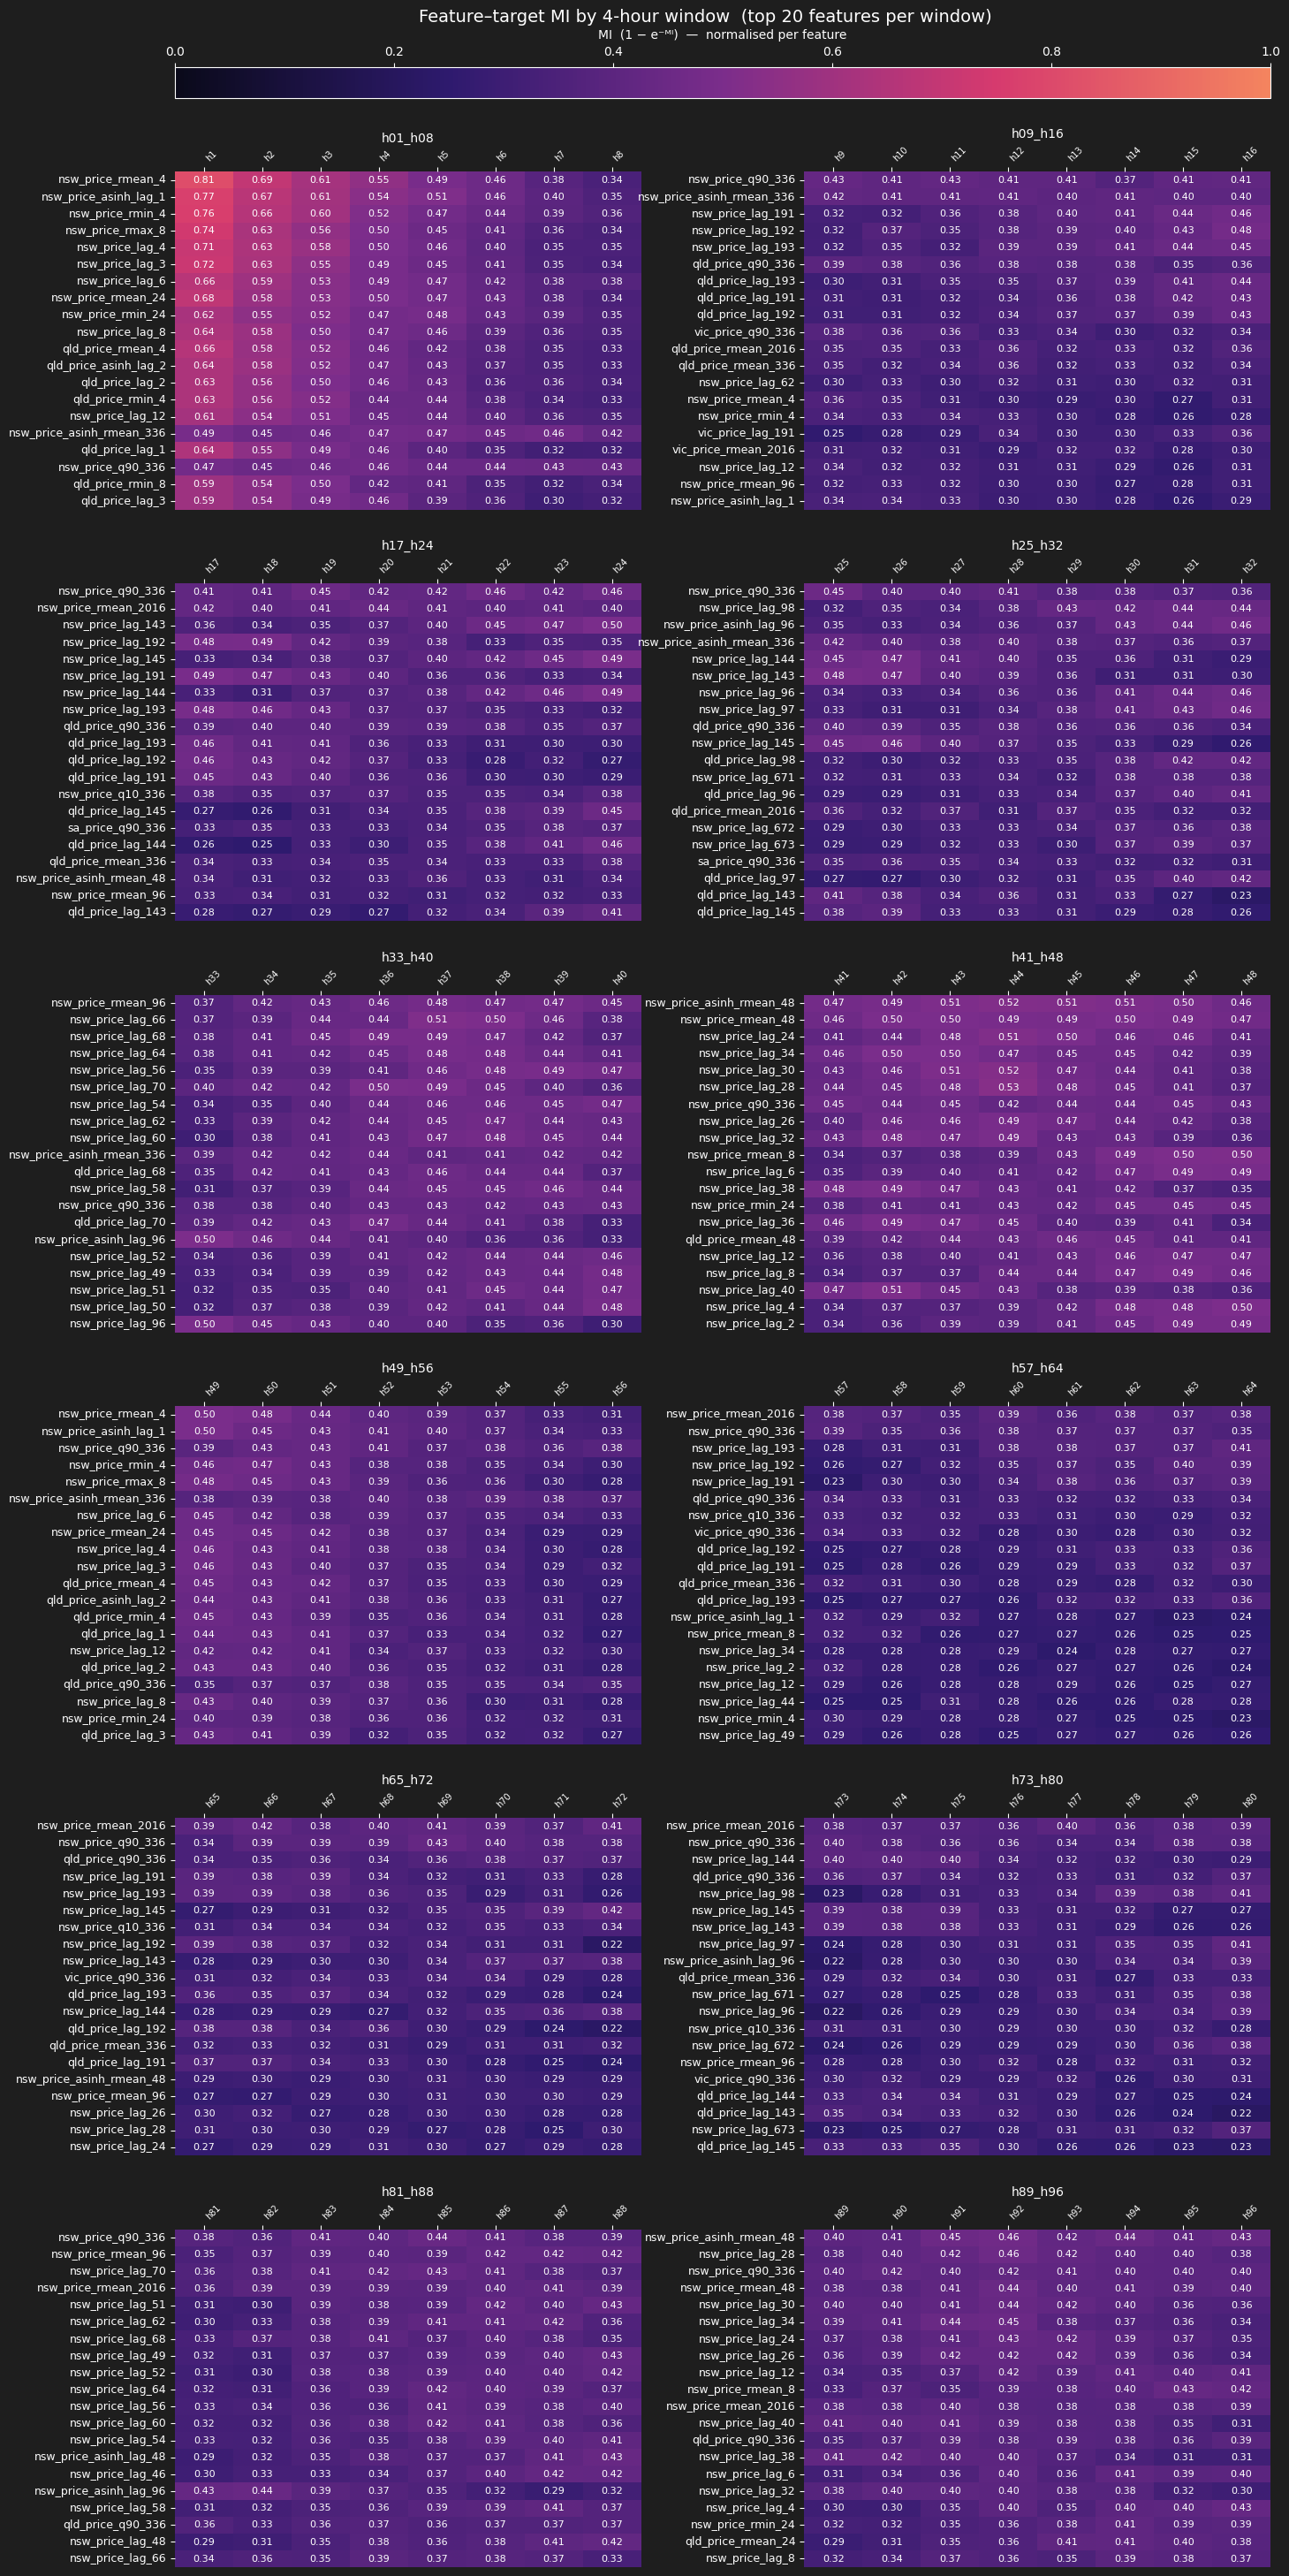

In [11]:
def mi_matrix_facets(window_selections: dict, window_mi_matrices: dict, top_n: int = 20, ncols: int = 4):
    """All 12 window MI heatmaps in one faceted figure with a shared colorbar."""
    labels = list(window_selections.keys())
    nrows  = (len(labels) + ncols - 1) // ncols

    _cmap = LinearSegmentedColormap.from_list(
        "mi_vibrant", ["#0a0a1a", "#2e1a6e", "#7b2d8b", "#d63a6e", "#f4845f"], N=256
    )

    # Pre-normalise each window's MI matrix, sorted by window MI, top_n features
    win_norms = {}
    for label, feats in window_selections.items():
        mi_win = window_mi_matrices[label].loc[feats]
        mi_win = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
        win_norms[label] = (1 - np.exp(-mi_win)).head(top_n)

    col_w   = 8
    row_h   = max(3.5, top_n * 0.27)
    CBAR_H  = 0.5

    with plt.style.context("dark_background"):
        fig = plt.figure(figsize=(col_w * ncols, row_h * nrows + CBAR_H))
        fig.patch.set_facecolor("#1e1e1e")

        gs = fig.add_gridspec(
            nrows + 1, ncols,
            height_ratios=[CBAR_H] + [row_h] * nrows,
            hspace=0.25, wspace=0.35,
            top=0.97,
        )
        cax = fig.add_subplot(gs[0, :])

        for idx, label in enumerate(labels):
            r = idx // ncols + 1
            c = idx % ncols
            ax = fig.add_subplot(gs[r, c])
            ax.set_facecolor("#1e1e1e")

            data       = win_norms[label]
            n_feat     = data.shape[0]
            annot_size = max(5, min(9, int(160 / max(n_feat, 1))))
            y_size     = max(6, min(9, int(200 / max(n_feat, 1))))

            sns.heatmap(
                data, ax=ax, cmap=_cmap, vmin=0, vmax=1,
                annot=True, fmt=".2f",
                annot_kws={"size": annot_size, "color": "white"},
                linewidths=0, linecolor="#2e2e2e", cbar=False,
            )
            ax.set_title(label, color="white", fontsize=10, pad=6)
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
            ax.tick_params(axis="x", labelsize=7, rotation=45, colors="white")
            ax.tick_params(axis="y", labelsize=y_size, rotation=0, colors="white")
            plt.setp(ax.get_xticklabels(), ha="left")

        # Shared colorbar in the top strip
        sm   = plt.cm.ScalarMappable(cmap=_cmap, norm=plt.Normalize(vmin=0, vmax=1))
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
        cbar.set_label("MI  (1 − e⁻ᴹᴵ)  —  normalised per feature", color="white", labelpad=6)
        cbar.ax.tick_params(colors="white")

        fig.suptitle(
            f"Feature–target MI by {HORIZONS_PER_WINDOW * OUTPUT_RESOLUTION // 60}-hour window  (top {top_n} features per window)",
            color="white", fontsize=14, y=0.99,
        )
        plt.show()


mi_matrix_facets(window_selections, window_mi_matrices, top_n=20, ncols=2)


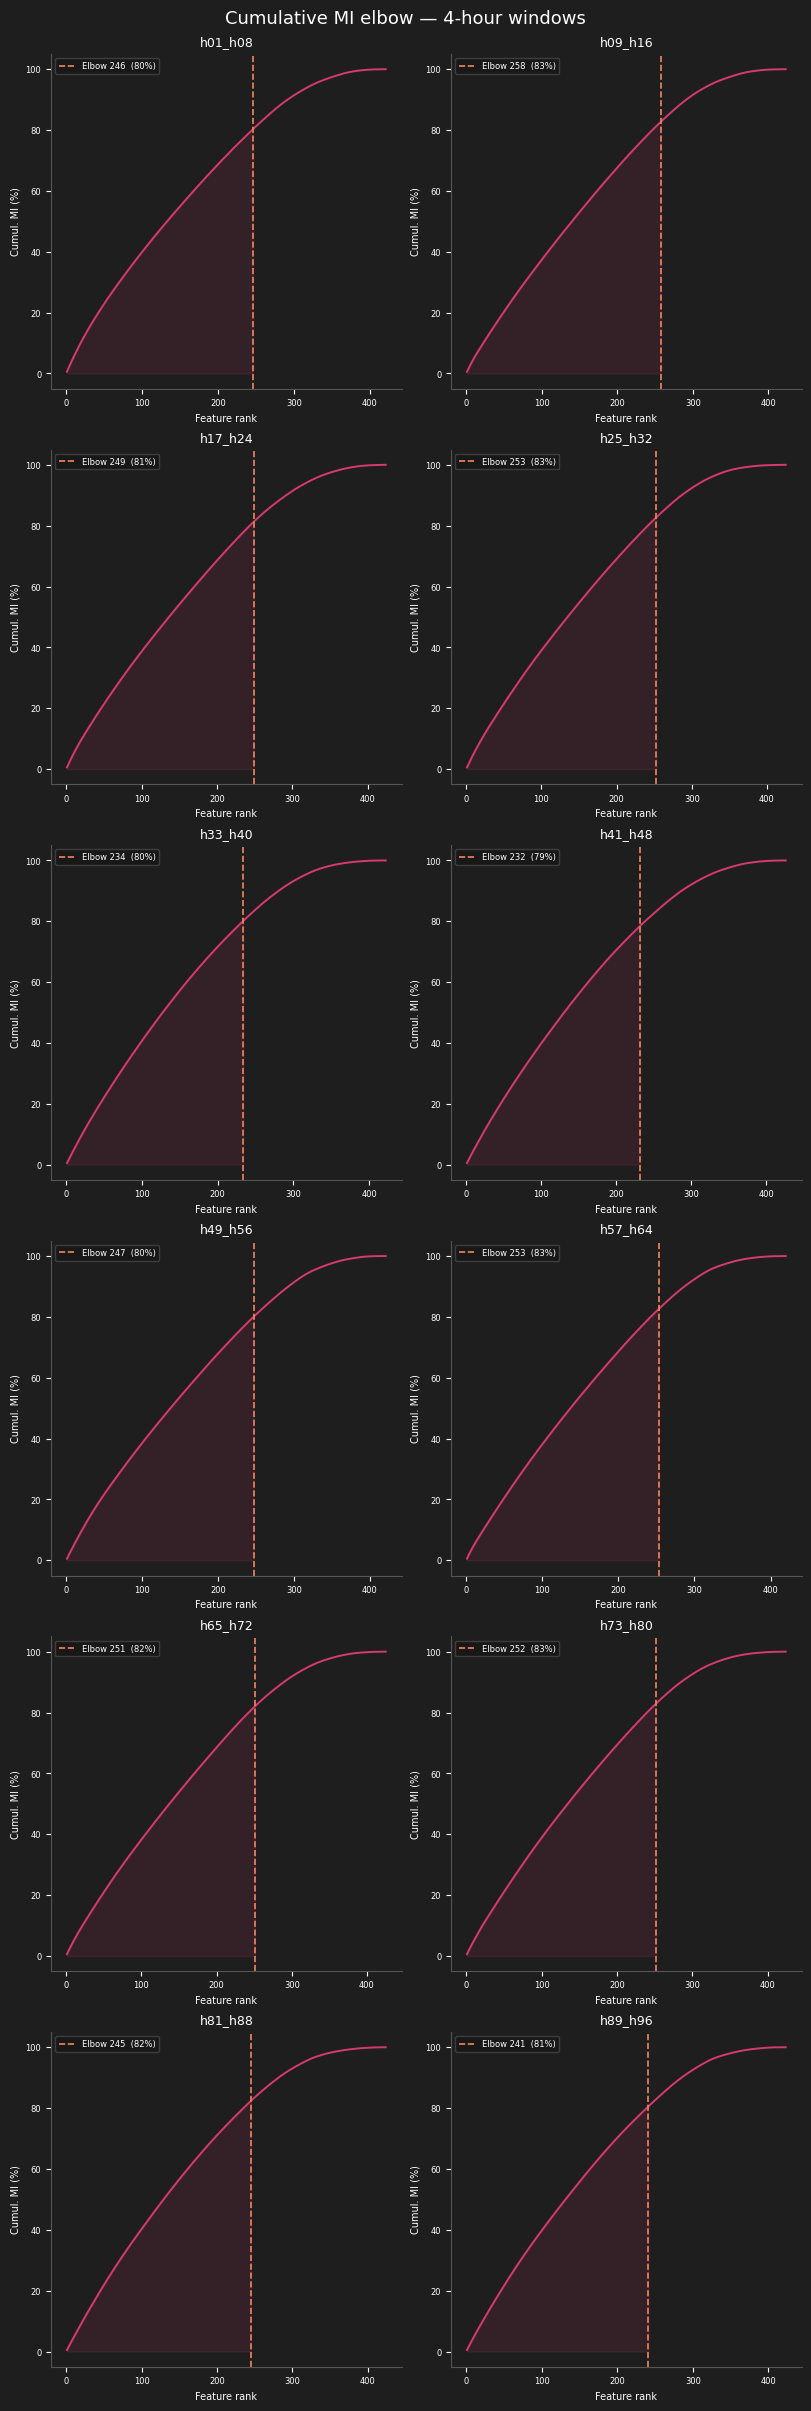

  h01_h08: elbow @ rank 246  (80.3% MI)  |  421 unique features
  h09_h16: elbow @ rank 258  (82.8% MI)  |  423 unique features
  h17_h24: elbow @ rank 249  (81.3% MI)  |  424 unique features
  h25_h32: elbow @ rank 253  (82.8% MI)  |  425 unique features
  h33_h40: elbow @ rank 234  (80.2% MI)  |  422 unique features
  h41_h48: elbow @ rank 232  (78.5% MI)  |  426 unique features
  h49_h56: elbow @ rank 247  (80.1% MI)  |  421 unique features
  h57_h64: elbow @ rank 253  (82.6% MI)  |  420 unique features
  h65_h72: elbow @ rank 251  (82.0% MI)  |  425 unique features
  h73_h80: elbow @ rank 252  (83.0% MI)  |  424 unique features
  h81_h88: elbow @ rank 245  (82.4% MI)  |  424 unique features
  h89_h96: elbow @ rank 241  (80.5% MI)  |  423 unique features


In [12]:
def _compute_elbow(mi_win_norm: pd.DataFrame) -> tuple[int, float, np.ndarray, np.ndarray]:
    """Compute cumulative MI elbow rank — pure calculation, no side effects."""
    mean_mi       = mi_win_norm.mean(axis=1).sort_values(ascending=False).values
    cumulative_mi = np.cumsum(mean_mi)
    total_mi      = cumulative_mi[-1]
    ranks         = np.arange(1, len(mean_mi) + 1)
    x_norm    = ranks / ranks[-1]
    y_norm    = cumulative_mi / total_mi
    line_vec  = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line_vec  = line_vec / np.linalg.norm(line_vec)
    point_vec = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
    perp_dist = np.abs(point_vec @ np.array([-line_vec[1], line_vec[0]]))
    elbow_idx = int(np.argmax(perp_dist))
    return elbow_idx + 1, 100 * cumulative_mi[elbow_idx] / total_mi, ranks, cumulative_mi / total_mi * 100, mean_mi


# ── Compute elbow for every window ───────────────────────────────────────────
window_elbow: dict[str, int] = {}
_elbow_data:  dict[str, dict] = {}

for label, feats in window_selections.items():
    mi_win      = window_mi_matrices[label].loc[feats]
    mi_win      = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
    mi_win_norm = 1 - np.exp(-mi_win)
    elbow_rank, pct, ranks, cum_pct, mean_mi = _compute_elbow(mi_win_norm)
    window_elbow[label] = elbow_rank
    _elbow_data[label]  = dict(elbow_rank=elbow_rank, pct=pct,
                                ranks=ranks, cum_pct=cum_pct,
                                mean_mi=mean_mi, n_feats=len(feats))

# ── Single 6 × 2 faceted figure ──────────────────────────────────────────────
_NCOLS = 2
_NROWS = 6
labels_ordered = list(window_elbow.keys())

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(
        _NROWS, _NCOLS,
        figsize=(_NCOLS * 4, _NROWS * 4),
        constrained_layout=True,
    )
    fig.patch.set_facecolor("#1e1e1e")
    fig.suptitle(
        f"Cumulative MI elbow — {HORIZONS_PER_WINDOW * OUTPUT_RESOLUTION // 60}-hour windows",
        color="white", fontsize=13,
    )

    for idx, label in enumerate(labels_ordered):
        r, c = divmod(idx, _NCOLS)
        ax   = axes[r, c]
        d    = _elbow_data[label]
        ax.set_facecolor("#1e1e1e")
        ax.plot(d['ranks'], d['cum_pct'], color="#d63a6e", linewidth=1.4)
        ax.axvline(d['elbow_rank'], color="#f4845f", linestyle="--", linewidth=1.2,
                   label=f"Elbow {d['elbow_rank']}  ({d['pct']:.0f}%)")
        ax.fill_between(d['ranks'], 0, d['cum_pct'],
                        where=(d['ranks'] <= d['elbow_rank']),
                        color="#d63a6e", alpha=0.12)
        ax.set_title(label, color="white", fontsize=9)
        ax.set_xlabel("Feature rank", color="white", fontsize=7)
        ax.set_ylabel("Cumul. MI (%)", color="white", fontsize=7)
        ax.tick_params(colors="white", labelsize=6)
        ax.legend(fontsize=6, framealpha=0.2, labelcolor="white")
        ax.spines[["top", "right"]].set_visible(False)
        for spine in ax.spines.values(): spine.set_edgecolor("#555")

    for idx in range(len(labels_ordered), _NROWS * _NCOLS):
        r, c = divmod(idx, _NCOLS)
        axes[r, c].set_visible(False)

    plt.show()

for label, elbow in window_elbow.items():
    d = _elbow_data[label]
    print(f"  {label}: elbow @ rank {elbow:3d}  ({d['pct']:.1f}% MI)  |  {d['n_feats']} unique features")


Validation (all windows × horizons): 100%|██████████| 192/192 [07:28<00:00,  2.33s/it]


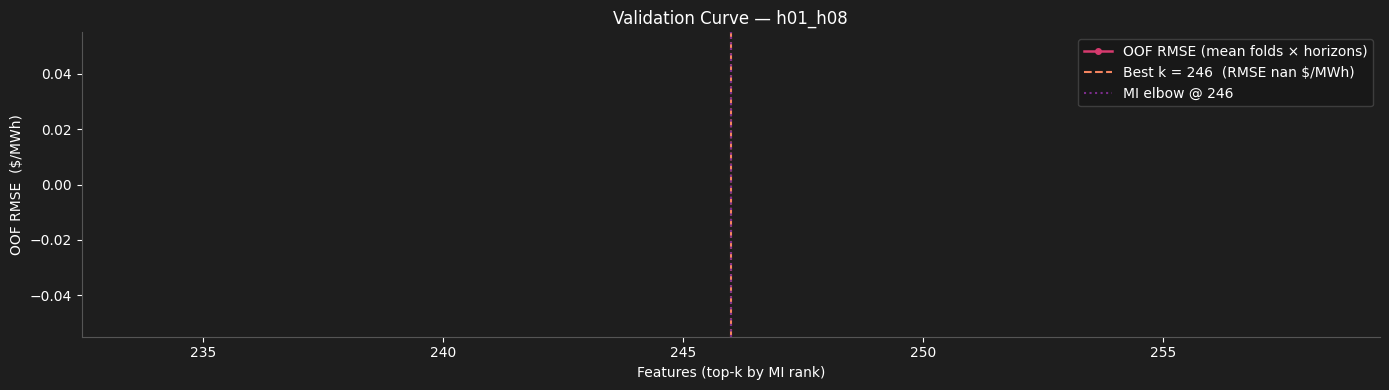

  h01_h08: best_k = 246  (OOF RMSE nan $/MWh)  |  MI elbow = 246  |  max_k = 421


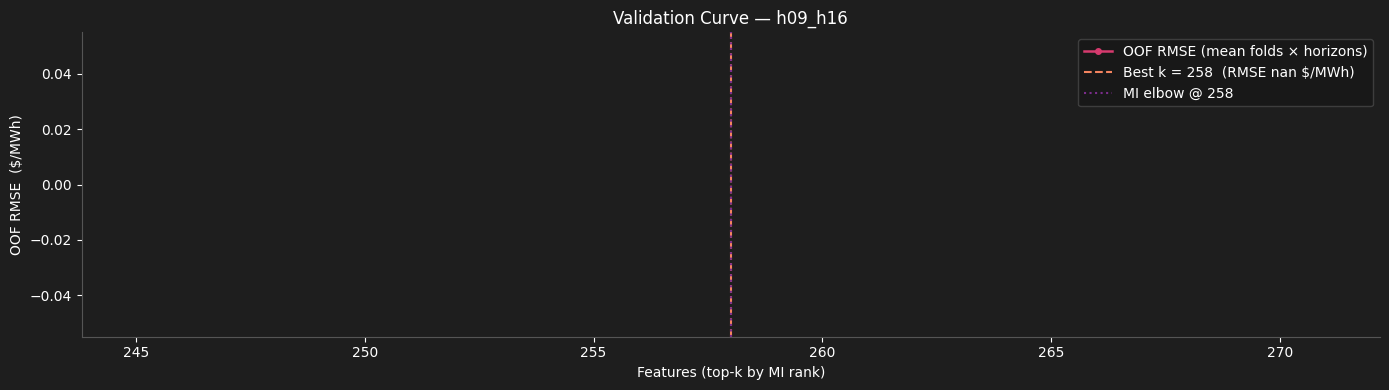

  h09_h16: best_k = 258  (OOF RMSE nan $/MWh)  |  MI elbow = 258  |  max_k = 423


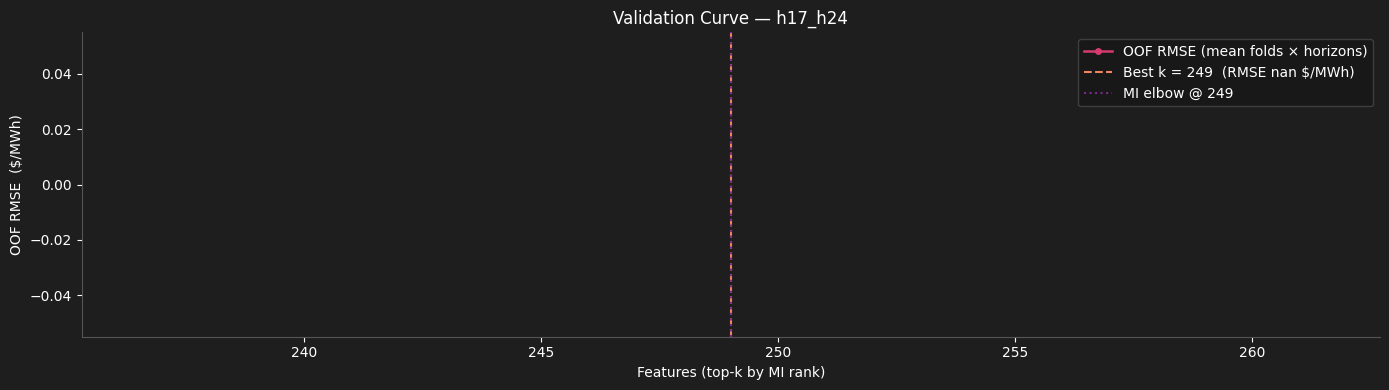

  h17_h24: best_k = 249  (OOF RMSE nan $/MWh)  |  MI elbow = 249  |  max_k = 424


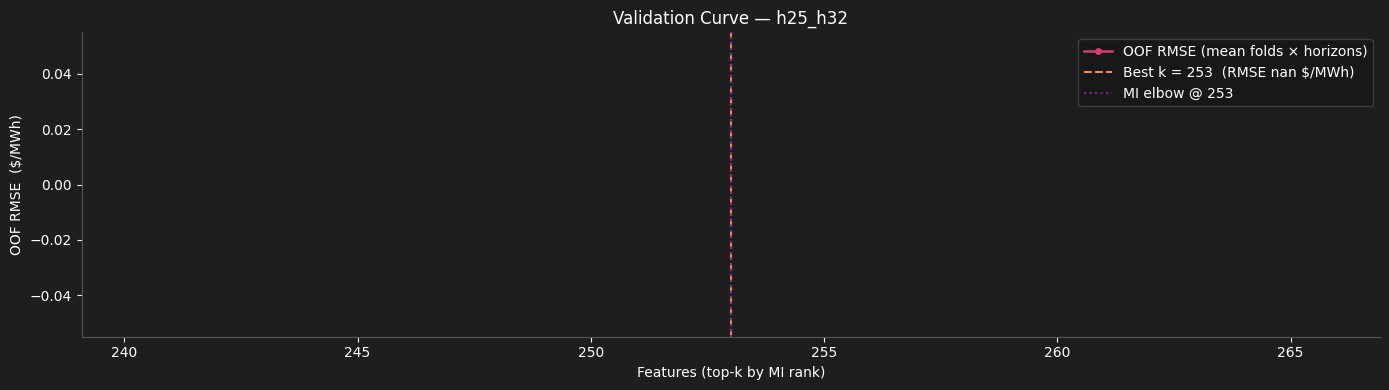

  h25_h32: best_k = 253  (OOF RMSE nan $/MWh)  |  MI elbow = 253  |  max_k = 425


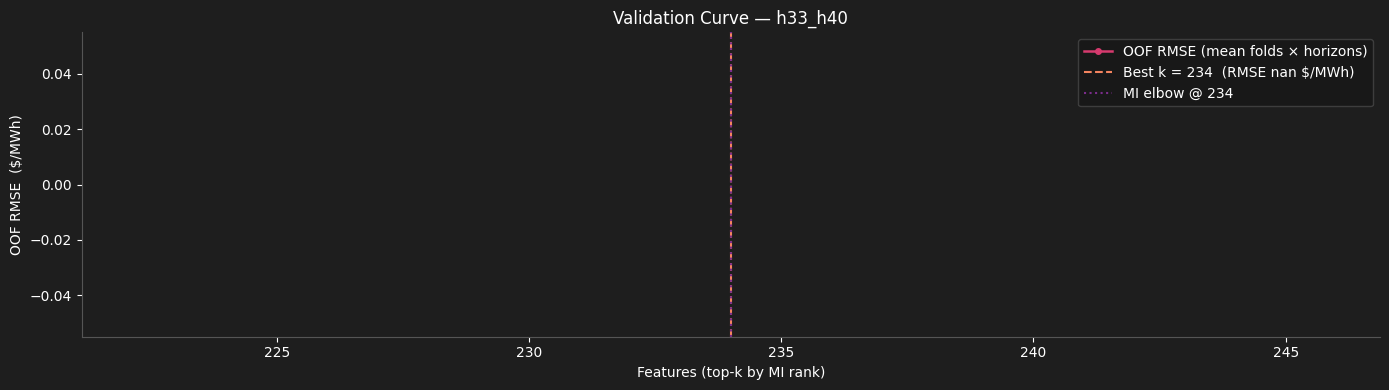

  h33_h40: best_k = 234  (OOF RMSE nan $/MWh)  |  MI elbow = 234  |  max_k = 422


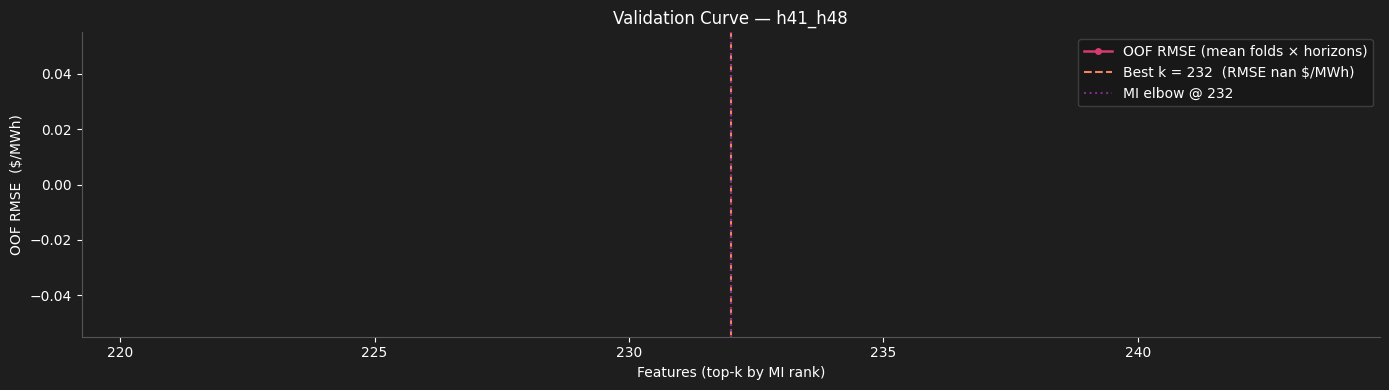

  h41_h48: best_k = 232  (OOF RMSE nan $/MWh)  |  MI elbow = 232  |  max_k = 426


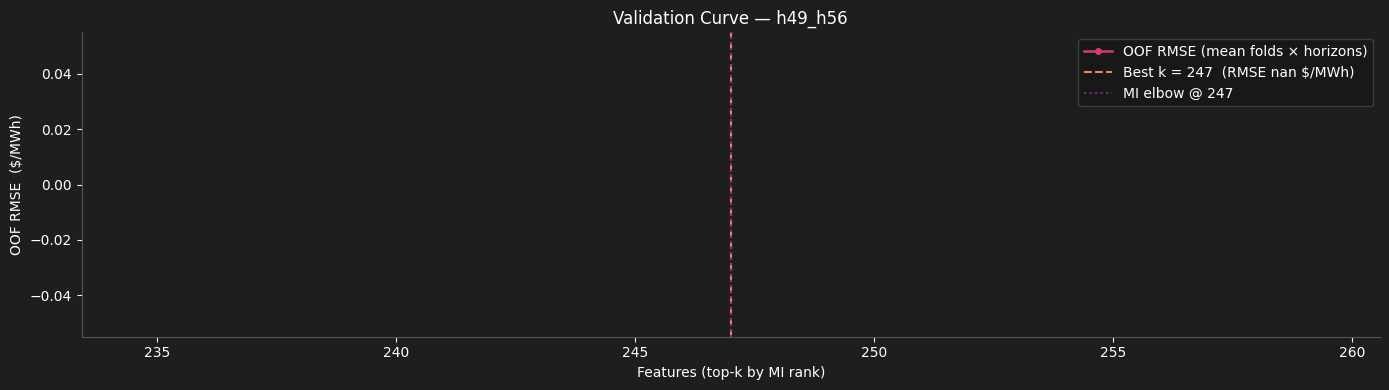

  h49_h56: best_k = 247  (OOF RMSE nan $/MWh)  |  MI elbow = 247  |  max_k = 421


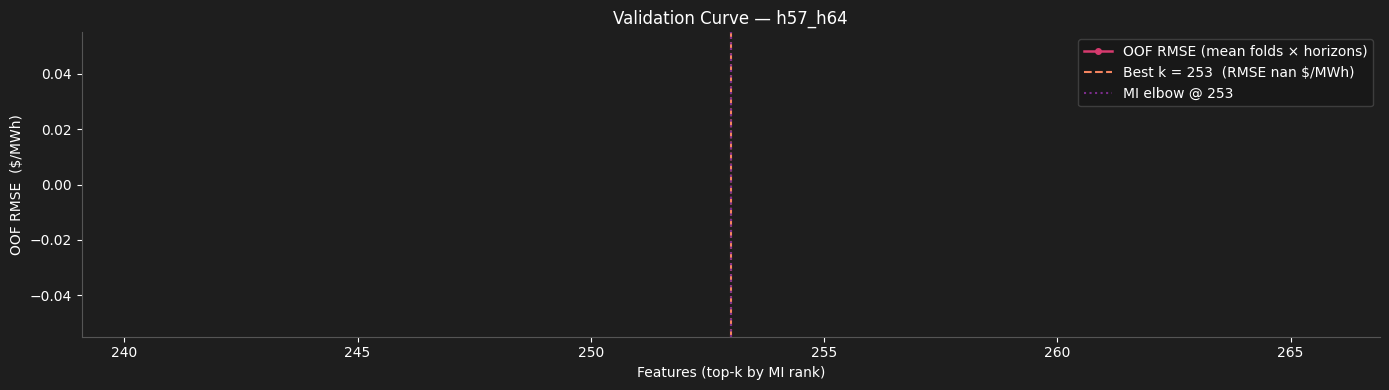

  h57_h64: best_k = 253  (OOF RMSE nan $/MWh)  |  MI elbow = 253  |  max_k = 420


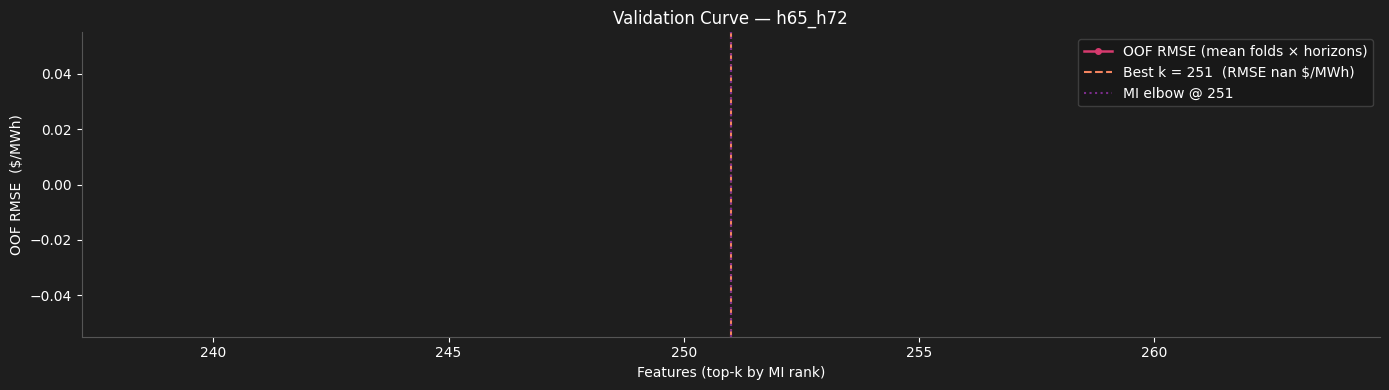

  h65_h72: best_k = 251  (OOF RMSE nan $/MWh)  |  MI elbow = 251  |  max_k = 425


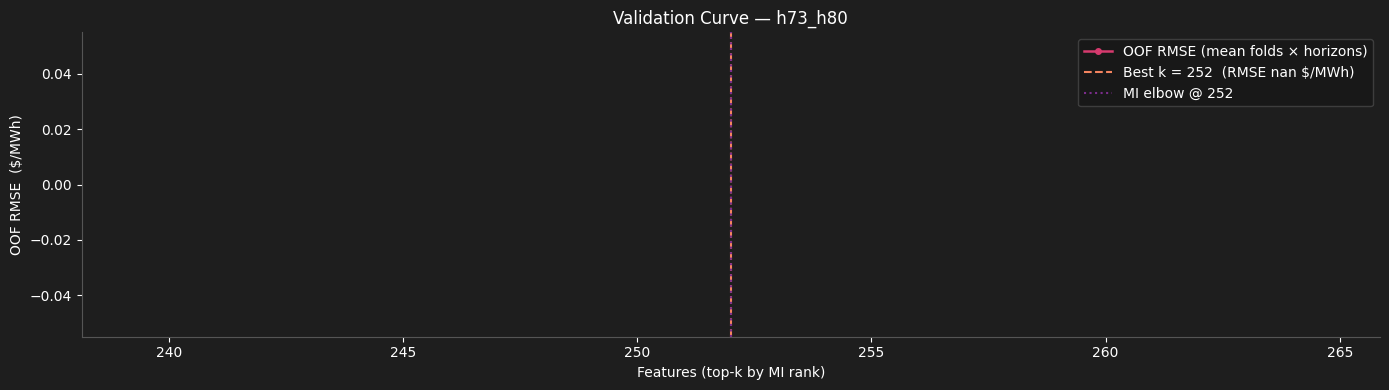

  h73_h80: best_k = 252  (OOF RMSE nan $/MWh)  |  MI elbow = 252  |  max_k = 424


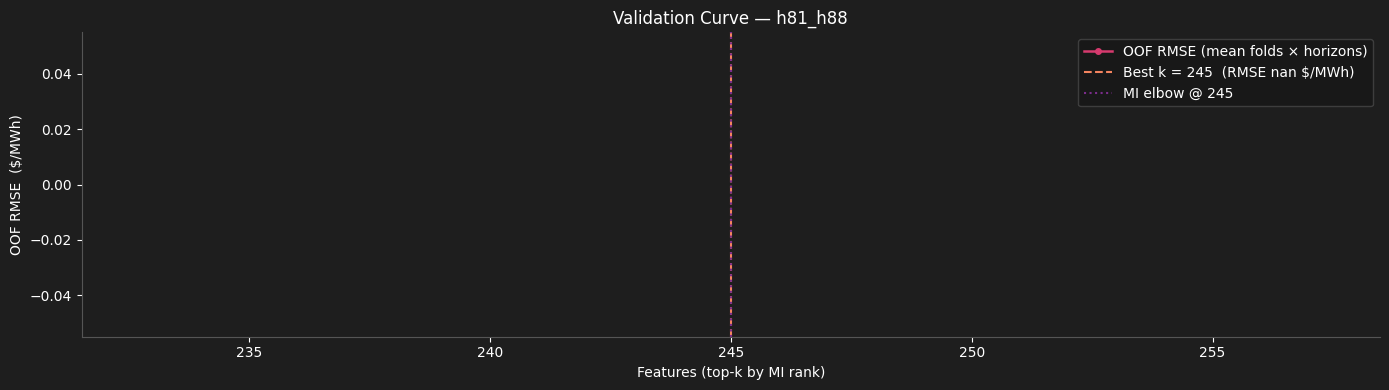

  h81_h88: best_k = 245  (OOF RMSE nan $/MWh)  |  MI elbow = 245  |  max_k = 424


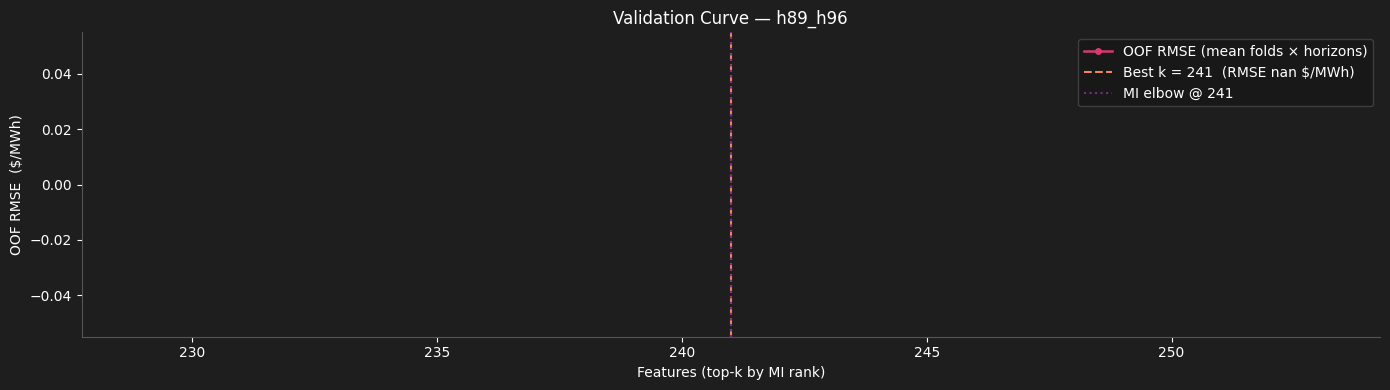

  h89_h96: best_k = 241  (OOF RMSE nan $/MWh)  |  MI elbow = 241  |  max_k = 423


In [13]:
def run_window_validation(
    window_selections: dict,
    window_mi_matrices: dict,
    features: pd.DataFrame,
    future_prediction_targets: pd.DataFrame,
    target_cols: list[str],
    window_elbow: dict,
    horizons_per_window: int,
    bucket_size: int,
    n_splits: int = 5,
) -> dict[str, int]:
    """
    Find best_k per window via a single parallel OOF validation pool.

    Design
    ------
    • Targets are aggregated from 5-min → output-resolution buckets first,
      giving `horizons_per_window` separate price series per window.
    • One LightGBM model is trained per (window, k, fold, horizon) with
      early stopping on the validation fold — no fixed tree budget.
    • Best_k minimises OOF RMSE averaged over all folds AND all horizons,
      capturing the full 4-hour-ahead prediction difficulty, not just the mean.
    • All 12 windows × k candidates × folds × horizons are dispatched to a
      single thread pool so the entire search runs in parallel.
    """
    import lightgbm as lgb
    from sklearn.model_selection import TimeSeriesSplit

    # ── Model params: swap TEST ↔ PROD ──────────────────────────────────────
    lgbm_params = dict(
        n_estimators=5,       # prod: 800
        learning_rate=0.25,    # prod: 0.03
        num_leaves=10,         # prod: 127
        min_child_samples=2, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=1, verbosity=-1, random_state=42,
    )

    # ── Pre-build per-window arrays (done once, shared across threads) ───────
    wd: dict[str, dict] = {}
    for w_idx, (label, feats) in enumerate(window_selections.items()):
        col_start = w_idx * horizons_per_window
        col_end   = col_start + horizons_per_window

        mi_win  = window_mi_matrices[label].loc[feats]
        mi_win  = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
        ranked  = (1 - np.exp(-mi_win)).mean(axis=1).sort_values(ascending=False).index.tolist()

        # 5-min → output-resolution aggregation  →  (n_rows, horizons_per_window)
        raw_cols = target_cols[col_start * bucket_size : col_end * bucket_size]
        raw_arr  = future_prediction_targets[raw_cols].values
        y_agg    = raw_arr.reshape(raw_arr.shape[0], horizons_per_window, bucket_size).mean(axis=2)
        y_df     = pd.DataFrame(y_agg, index=future_prediction_targets.index)

        shared  = features.index.intersection(y_df.index)
        X       = features.loc[shared][ranked].values.astype(np.float32)   # columns = MI rank order
        y       = y_df.loc[shared].values.astype(np.float32)
        splits  = list(TimeSeriesSplit(n_splits=n_splits).split(X))

        max_k   = len(ranked)
        elbow   = window_elbow.get(label) or max(5, max_k // 5)

        # ── k search grid: swap TEST ↔ PROD ──────────────────────────────
        base_k  = sorted({elbow})                                     # prod: sorted({5, 10, 20, 30, 50, 80, 120, 180, 250, 350, max_k})
        near_k  = []                                                  # prod: [max(1, elbow + d) for d in range(-12, 13, 2)]
        k_vals  = sorted({k for k in {*base_k, *near_k, elbow} if 1 <= k <= max_k})

        wd[label] = dict(ranked=ranked, k_vals=k_vals, X=X, y=y,
                         splits=splits, elbow=elbow, max_k=max_k)

    # ── Flat task list: one entry per (window, k_idx, fold_idx, horizon) ────
    tasks = [
        (label, ki, fi, h)
        for label, d in wd.items()
        for ki in range(len(d['k_vals']))
        for fi in range(len(d['splits']))
        for h  in range(horizons_per_window)
    ]

    def _fit(label: str, ki: int, fi: int, h: int):
        import warnings
        d = wd[label]
        k = d['k_vals'][ki]
        tr, va = d['splits'][fi]
        X_tr, X_va = d['X'][tr, :k], d['X'][va, :k]
        y_tr, y_va = d['y'][tr, h],  d['y'][va, h]
        m = lgb.LGBMRegressor(**lgbm_params)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(5, verbose=False),    # prod: 50
                         lgb.log_evaluation(-1)])
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="X does not have valid feature names",
                                    category=UserWarning)
            preds = m.predict(X_va)
        return label, ki, fi, h, float(np.sqrt(np.mean((preds - y_va) ** 2)))

    acc = {
        label: np.full((len(d['k_vals']), n_splits, horizons_per_window), np.nan)
        for label, d in wd.items()
    }
    gen = Parallel(n_jobs=-1, prefer="threads", batch_size=1, return_as="generator_unordered")(  # prod: batch_size="auto"
        delayed(_fit)(*t) for t in tasks
    )
    for label, ki, fi, h, rmse in tqdm(gen, total=len(tasks),
                                        desc="Validation (all windows × horizons)"):
        acc[label][ki, fi, h] = rmse

    # ── Compute best_k per window ─────────────────────────────────────────────
    window_best_k: dict[str, int] = {}
    _plot_data: dict[str, dict] = {}
    for label, d in wd.items():
        rmse_per_k = acc[label].mean(axis=(1, 2)).tolist()
        bi         = int(np.argmin(rmse_per_k))
        best_k     = d['k_vals'][bi]
        best_rmse  = rmse_per_k[bi]
        window_best_k[label] = best_k
        _plot_data[label] = dict(k_vals=d['k_vals'], rmse_per_k=rmse_per_k,
                                  best_k=best_k, best_rmse=best_rmse, elbow=d['elbow'],
                                  max_k=d['max_k'])
        print(f"  {label}: best_k = {best_k}  (OOF RMSE {best_rmse:.4f} $/MWh)"
              f"  |  MI elbow = {d['elbow']}  |  max_k = {d['max_k']}")

    # ── Faceted 2 × 6 validation curves ──────────────────────────────────────
    _NCOLS = 2
    _NROWS = 6
    labels_ordered = list(_plot_data.keys())

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(
            _NROWS, _NCOLS,
            figsize=(_NCOLS * 7, _NROWS * 3),
            constrained_layout=True,
        )
        fig.patch.set_facecolor("#1e1e1e")
        fig.suptitle(
            f"Validation Curves — {horizons_per_window * 30 // 60}-hour windows",
            color="white", fontsize=13,
        )
        for idx, label in enumerate(labels_ordered):
            r, c = divmod(idx, _NCOLS)
            ax   = axes[r, c]
            p    = _plot_data[label]
            ax.set_facecolor("#1e1e1e")
            ax.plot(p['k_vals'], p['rmse_per_k'], color="#d63a6e", linewidth=1.4,
                    marker="o", markersize=3, label="OOF RMSE")
            ax.axvline(p['best_k'], color="#f4845f", linestyle="--", linewidth=1.2,
                       label=f"Best k={p['best_k']}  ({p['best_rmse']:.2f})")
            ax.scatter([p['best_k']], [p['best_rmse']], color="#f4845f", zorder=5, s=40)
            ax.axvline(p['elbow'], color="#7b2d8b", linestyle=":", linewidth=1.2,
                       label=f"Elbow={p['elbow']}")
            ax.set_title(label, color="white", fontsize=9)
            ax.set_xlabel("Top-k features", color="white", fontsize=7)
            ax.set_ylabel("OOF RMSE ($/MWh)", color="white", fontsize=7)
            ax.tick_params(colors="white", labelsize=6)
            ax.legend(fontsize=6, framealpha=0.2, labelcolor="white")
            ax.spines[["top", "right"]].set_visible(False)
            for spine in ax.spines.values(): spine.set_edgecolor("#555")

        for idx in range(len(labels_ordered), _NROWS * _NCOLS):
            r, c = divmod(idx, _NCOLS)
            axes[r, c].set_visible(False)

        plt.show()

    return window_best_k


BUCKET_SIZE   = OUTPUT_RESOLUTION // 5   # 5-min intervals per output-resolution bucket
window_best_k = run_window_validation(
    window_selections=window_selections,
    window_mi_matrices=window_mi_matrices,
    features=features,
    future_prediction_targets=future_prediction_targets,
    target_cols=target_cols,
    window_elbow=window_elbow,
    horizons_per_window=HORIZONS_PER_WINDOW,
    bucket_size=BUCKET_SIZE,
    n_splits=1,    # prod: 5
)


In [15]:
# Update window_features.parquet with is_selected (top best_k per window)
df_windows = pd.read_parquet(windows_path)
df_windows["best_k"]      = df_windows["window"].map(window_best_k)
df_windows["is_selected"] = df_windows["rank_in_window"] <= df_windows["best_k"]
df_windows.to_parquet(windows_path, index=False)

print(f"Updated {windows_path} with is_selected")
for lbl, k in window_best_k.items():
    n_sel = (df_windows[df_windows["window"] == lbl]["is_selected"]).sum()
    print(f"  {lbl}: {n_sel} selected (best_k={k})")

df_windows.head(16)

Updated Selected_features/NSW_1_dispatch_price_feature_ranking.parquet with is_selected
  h01_h08: 246 selected (best_k=246)
  h09_h16: 258 selected (best_k=258)
  h17_h24: 249 selected (best_k=249)
  h25_h32: 253 selected (best_k=253)
  h33_h40: 234 selected (best_k=234)
  h41_h48: 232 selected (best_k=232)
  h49_h56: 247 selected (best_k=247)
  h57_h64: 253 selected (best_k=253)
  h65_h72: 251 selected (best_k=251)
  h73_h80: 252 selected (best_k=252)
  h81_h88: 245 selected (best_k=245)
  h89_h96: 241 selected (best_k=241)


,window,window_start_h,window_end_h,rank_in_window,feature,mean_mi_window,state,feature_dataset,best_k,is_selected
0,h01_h08,h01,h08,1,nsw_price_rmean_4,0.851929,NSW,1_dispatch_price,246,True
1,h01_h08,h01,h08,2,nsw_price_asinh_lag_1,0.816269,NSW,1_dispatch_price,246,True
2,h01_h08,h01,h08,3,nsw_price_rmin_4,0.790210,NSW,1_dispatch_price,246,True
3,h01_h08,h01,h08,4,nsw_price_rmax_8,0.729160,NSW,1_dispatch_price,246,True
4,h01_h08,h01,h08,5,nsw_price_lag_4,0.723603,NSW,1_dispatch_price,246,True
5,h01_h08,h01,h08,6,nsw_price_lag_3,0.710219,NSW,1_dispatch_price,246,True
6,h01_h08,h01,h08,7,nsw_price_lag_6,0.695541,NSW,1_dispatch_price,246,True
7,h01_h08,h01,h08,8,nsw_price_rmean_24,0.694389,NSW,1_dispatch_price,246,True
8,h01_h08,h01,h08,9,nsw_price_rmin_24,0.660876,NSW,1_dispatch_price,246,True
9,h01_h08,h01,h08,10,nsw_price_lag_8,0.651397,NSW,1_dispatch_price,246,True
